In [1]:
# Import libraries
import pandas as pd  # for Data preprocessing
import matplotlib.pyplot as plt  # for Data Visualization
import seaborn as sns  # for Data Visualization


In [2]:
cleaned_customer_transaction_data =pd.read_csv(r"C:\Users\oyebi\Fraudulent-Transaction-Detection\Dataset\artifacts\cleaned_customer_transaction_data.csv")

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis was conducted to understand the characteristics of the FinLora transaction dataset, identify patterns associated with fraudulent transactions, assess data distributions, investigate relationships between variables, and identify potential predictors of fraud.


 ### Target Variable Distribution (`is_fraud`)

The target variable `is_fraud` shows a clear class imbalance.

| Fraud Status | Count | Percentage |
|---|---:|---:|
| Legitimate Transactions (`0`) | 10,403 | 91.25% |
| Fraudulent Transactions (`1`) | 997 | 8.75% |

Most transactions in the dataset are legitimate, accounting for 91.25% of all observations, while fraudulent transactions represent only 8.75%.

This imbalance is important for the machine learning stage because a model could achieve high accuracy by predicting mainly the majority class. Therefore, accuracy alone should not be used to evaluate model performance. Metrics such as precision, recall, F1-score, confusion matrix will  also be considered.

Class imbalance handling techniques such as class weighting will also be evaluated during model development.

In [3]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.1,
    palette="Spectral"
    ) # spectral gives different clolours.

In [4]:
cleaned_customer_transaction_data.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='object')

### Comparing fraud distribution across key variables

In [5]:
cleaned_customer_transaction_data['is_fraud'].value_counts()

                                  

is_fraud
0    9799
1     981
Name: count, dtype: int64

In [6]:
cleaned_customer_transaction_data['channel'].value_counts()

channel
mobile    6155
web       3659
atm        966
Name: count, dtype: int64

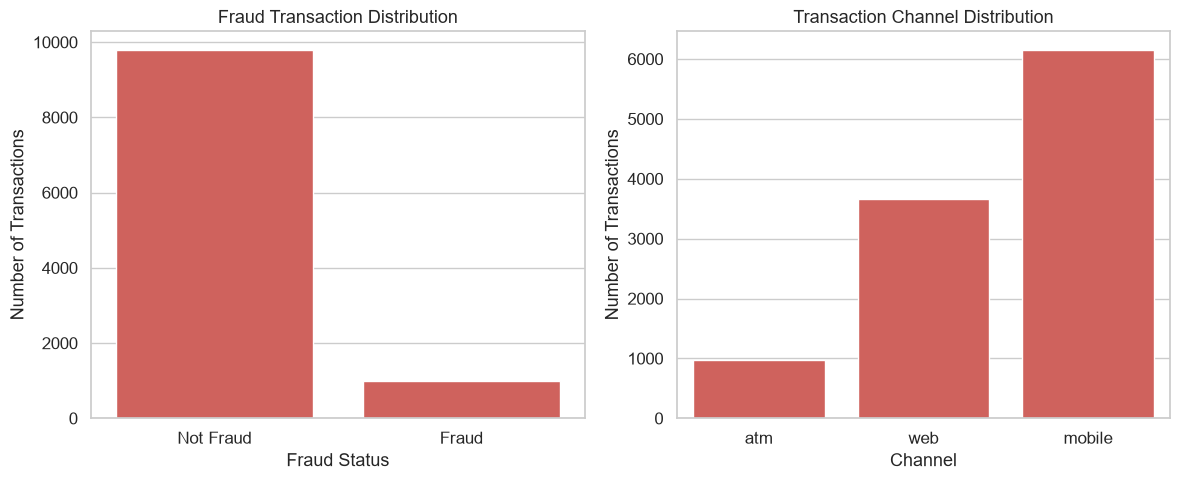

In [7]:
fig, axes= plt.subplots(nrows=1, ncols =2, figsize = (12,5))

# Fraud Distribution
sns.countplot(x = 'is_fraud', data = cleaned_customer_transaction_data, ax=axes[0]) # axes 0 means the first column
axes[0].set_title('Fraud Transaction Distribution')
axes[0].set_xlabel('Fraud Status')  
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(["Not Fraud", "Fraud"])


# Channel Distribution
sns.countplot(x = 'channel',     data = cleaned_customer_transaction_data, ax=axes[1]) # axes 1 means the second column
axes[1].set_title('Transaction Channel Distribution')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout()  # Adjusts the spacing between subplots to prevent overlap
plt.show()


##### Mobile is the most frequently used transaction channel (6155), followed by Web (3659) and ATM (966). However, transaction volume alone does not indicate fraud risk; the fraud rate within each channel will be compared to identify the channel most associated with fraud.

#### IP Country and KYC Tier Analysis

The analysis examines the distribution of transactions across **IP countries and KYC tiers** and their relationship with fraud. IP country analysis helps identify the geographic origin of transactions and whether fraud is more concentrated in particular locations.

KYC tier analysis shows how transactions are distributed across different customer verification levels and whether fraud occurrence varies by KYC status.

Overall, these analyses help determine whether **transaction location and KYC verification level may be useful indicators of fraudulent activity** and potential features for the fraud detection model.


In [8]:
# IP Country Analysis
cleaned_customer_transaction_data['ip_country'].value_counts()

ip_country
us    6712
uk    2354
ca    1686
Name: count, dtype: int64

In [9]:
# KYC Tier Analysis
cleaned_customer_transaction_data['kyc_tier'].value_counts()

kyc_tier
standard    7911
enhanced    1833
low         1036
Name: count, dtype: int64

In [10]:
ip_country_fraud = (
    cleaned_customer_transaction_data
    .groupby('ip_country', dropna=False)['is_fraud']
    .agg(
        Total_Transactions='count',
        Fraud_Count='sum',
        Fraud_Rate='mean'
    )
)

ip_country_fraud

,Total_Transactions,Fraud_Count,Fraud_Rate
ip_country,,,
ca,1686,302,0.179122
uk,2354,354,0.150382
us,6712,325,0.048421
NaN,28,0,0.000000


In [11]:
kyc_fraud = (
    cleaned_customer_transaction_data
    .groupby('kyc_tier')['is_fraud']
    .agg(
        Total_Transactions='count',
        Fraud_Count='sum',
        Fraud_Rate='mean'
    )
)
kyc_fraud

,Total_Transactions,Fraud_Count,Fraud_Rate
kyc_tier,,,
enhanced,1833,41,0.022368
low,1036,535,0.516409
standard,7911,405,0.051195


In [12]:
# KYC Tier Analysis, # IP Country Analysis, # comparingIP country with fraud status, # comparing KYC tier with fraud status

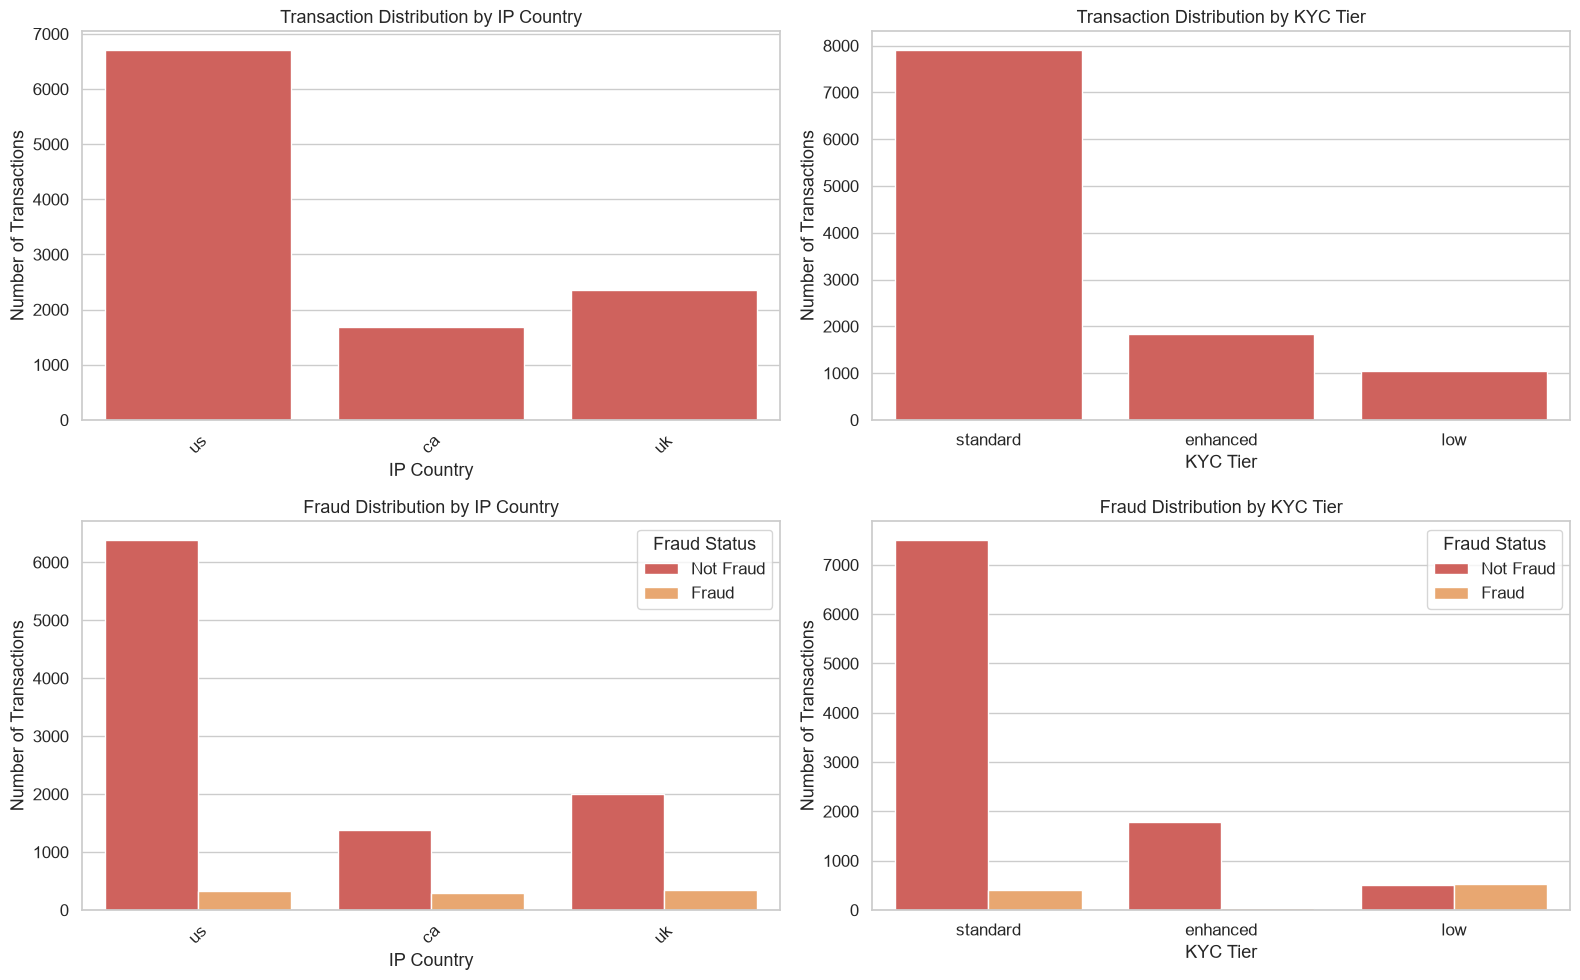

In [13]:
fig, axes = plt.subplots(2, 2,  figsize=(16, 10))

# 1. IP Country Distribution
sns.countplot(
    x='ip_country',
      data=cleaned_customer_transaction_data,
        ax=axes[0, 0]
)
axes[0, 0].set_title('Transaction Distribution by IP Country')
axes[0, 0].set_xlabel('IP Country')
axes[0, 0].set_ylabel('Number of Transactions')
axes[0, 0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better visibility

# 2. KYC Tier Distribution
sns.countplot(
    x='kyc_tier',
      data=cleaned_customer_transaction_data,
        ax=axes[0, 1]
)
axes[0, 1].set_title('Transaction Distribution by KYC Tier')
axes[0, 1].set_xlabel('KYC Tier')
axes[0, 1].set_ylabel('Number of Transactions')

# 3. IP Country vs Fraud Status
sns.countplot(
    x='ip_country',
      hue='is_fraud',
        data=cleaned_customer_transaction_data,
          ax=axes[1, 0]
)
axes[1, 0].set_title('Fraud Distribution by IP Country')
axes[1, 0].set_xlabel('IP Country')
axes[1, 0].set_ylabel('Number of Transactions')
axes[1, 0].tick_params(axis='x', rotation=45) 
axes[1, 0].legend(title='Fraud Status', labels=['Not Fraud', 'Fraud'])

# 4. KYC Tier vs Fraud Status
sns.countplot(  
    x='kyc_tier',
      hue='is_fraud',
        data=cleaned_customer_transaction_data,
          ax=axes[1, 1]
)
axes[1, 1].set_title('Fraud Distribution by KYC Tier')
axes[1, 1].set_xlabel('KYC Tier')
axes[1, 1].set_ylabel('Number of Transactions')
axes[1, 1].legend(title='Fraud Status', labels=['Not Fraud', 'Fraud'])

plt.tight_layout()  
plt.show()

### EDA Summary – IP Country and Fraud

The analysis shows clear differences in fraud occurrence across IP countries. The **US recorded the highest transaction volume (6,712)** but had the **lowest fraud rate (4.84%)**. Canada recorded **1,686 transactions and the highest fraud rate (17.91%)**, while the UK recorded **2,354 transactions with a fraud rate of 15.04%**.

Although the UK had the highest absolute number of fraud cases (354), Canada had the highest proportion of fraudulent transactions. The 28 transactions with missing IP country information recorded no fraud cases.

Overall, the variation in fraud rates suggests that **IP country may be a useful feature for fraud detection**, particularly when combined with other customer and transaction risk indicators.


### EDA Summary – KYC Tier and Fraud

The analysis shows a strong difference in fraud occurrence across KYC tiers. The **standard KYC tier** accounted for the largest transaction volume with 7,911 transactions, followed by enhanced KYC with 1,833 and low KYC with 1,036 transactions.

The **low KYC tier recorded by far the highest fraud rate at 51.64%**, with 535 of its 1,036 transactions classified as fraudulent. In comparison, the standard KYC tier had a fraud rate of **5.12%**, while the enhanced KYC tier recorded the lowest fraud rate at **2.24%**.

This indicates a strong association between KYC verification level and fraudulent activity in this dataset. Transactions associated with the low KYC tier appear substantially more likely to be fraudulent than those associated with standard or enhanced verification. Therefore, **KYC tier is potentially an important predictive feature for the fraud detection model**.




#### Fraud per channel, Fraud

C:\Users\oyebi\AppData\Local\Temp\ipykernel_6372\3990429297.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\oyebi\AppData\Local\Temp\ipykernel_6372\3990429297.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


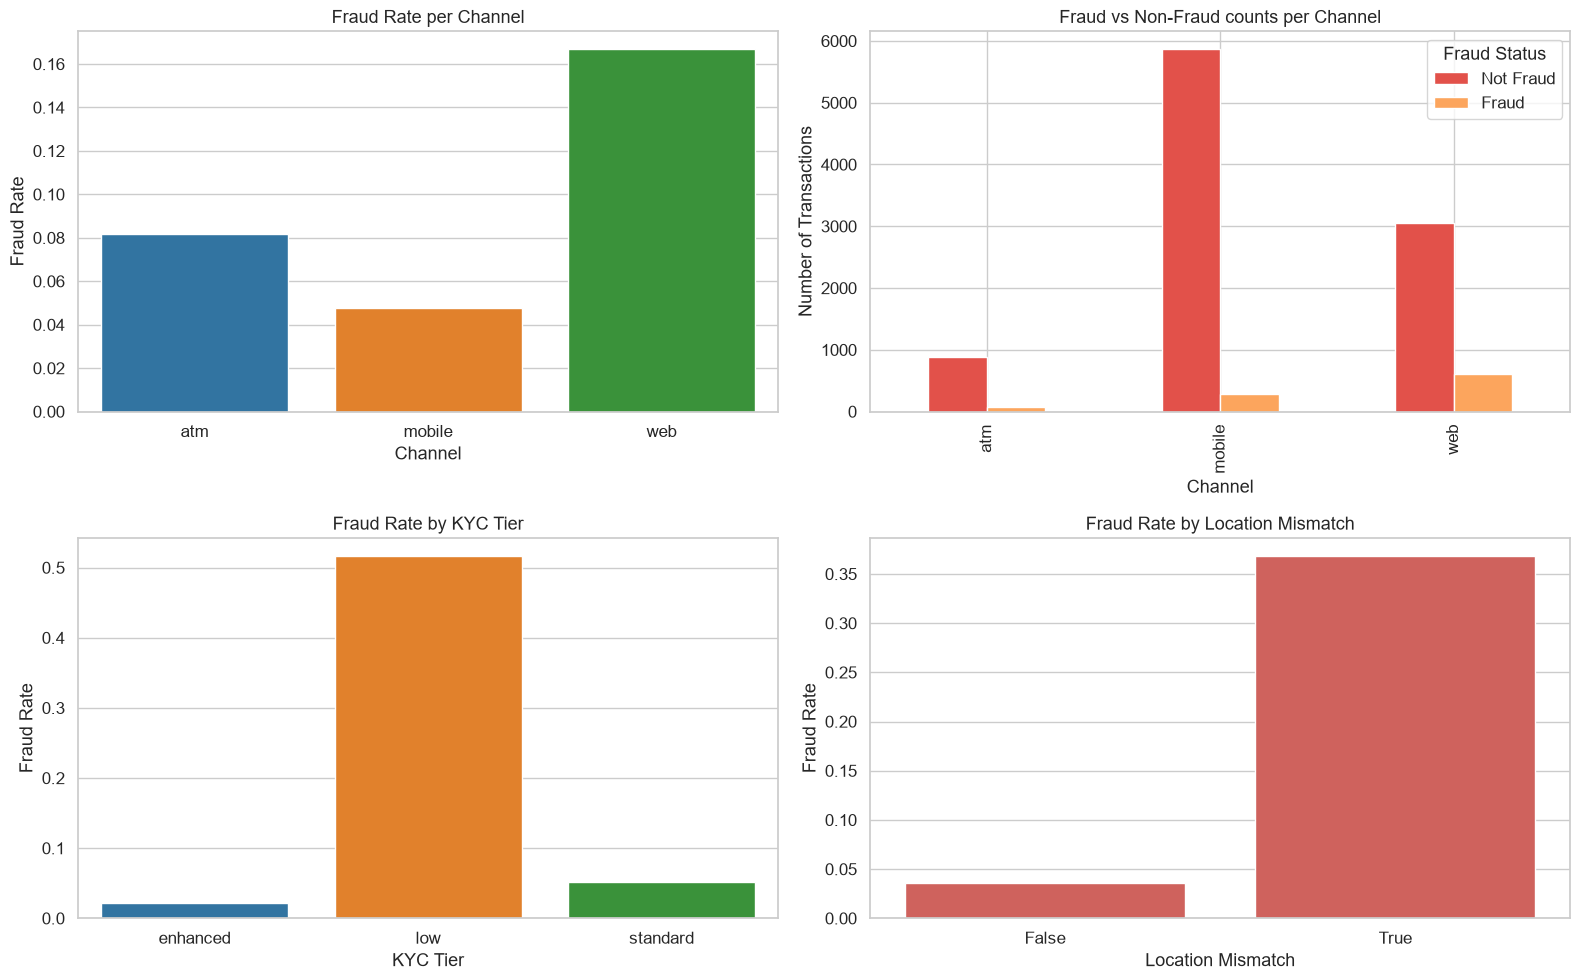

In [14]:
import matplotlib.pyplot as plt  
import seaborn as sns  

fig, axes = plt.subplots(2,2, figsize= (16,10))

# 1. Fraud rate per channel
channel_fraud_rate = cleaned_customer_transaction_data.groupby('channel')['is_fraud'].mean().reset_index()

channel_fraud_rate

sns.barplot(
    x='channel',
      y='is_fraud',
        data=channel_fraud_rate, 
        ax=axes[0,0],
palette = 'tab10' 
)

axes[0,0].set_title('Fraud Rate per Channel')      
axes[0,0].set_xlabel('Channel') 
axes[0,0].set_ylabel('Fraud Rate')


# 2. Fraud vs Non-Fraud Transactions per Channel
channel_counts = (
    cleaned_customer_transaction_data.groupby('channel')['is_fraud']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

channel_counts = channel_counts.rename(
    columns={0: 'Not Fraud', 1: 'Fraud'}
)

channel_counts.plot(
    x='channel',
      y=['Not Fraud', 'Fraud'], 
      kind='bar',
        ax=axes[0,1]
)

axes[0,1].set_title('Fraud vs Non-Fraud counts per Channel')
axes[0,1].set_xlabel('Channel') 
axes[0,1].set_ylabel('Number of Transactions')
axes[0,1].legend(title='Fraud Status')


# 3. Fraud rate per KYC tier
kyc_fraud_rate = cleaned_customer_transaction_data.groupby('kyc_tier')['is_fraud'].mean().reset_index()

sns.barplot(
    data =kyc_fraud_rate,
    x='kyc_tier',
    y = 'is_fraud',
    ax=axes[1,0],
    palette = 'tab10'
)

axes[1,0].set_title('Fraud Rate by KYC Tier')
axes[1,0].set_xlabel('KYC Tier')
axes[1,0].set_ylabel('Fraud Rate')


# 4. Fraud rate per location mismatch
location_fraud_rate = (
    cleaned_customer_transaction_data.groupby('location_mismatch')['is_fraud']
    .mean()
    .reset_index(0)
)


sns.barplot(
    data= location_fraud_rate,
    x = 'location_mismatch',
    y = 'is_fraud',
    ax= axes[1,1],

)

axes[1,1].set_title('Fraud Rate by Location Mismatch')
axes[1,1].set_xlabel('Location Mismatch')
axes[1,1].set_ylabel('Fraud Rate')


plt.tight_layout()
plt.show()



In [15]:
channel_fraud_rate

,channel,is_fraud
0,atm,0.081781
1,mobile,0.047441
2,web,0.166712


In [16]:
channel_counts

is_fraud,channel,Not Fraud,Fraud
0,atm,887,79
1,mobile,5863,292
2,web,3049,610


In [17]:
kyc_fraud_rate

,kyc_tier,is_fraud
0,enhanced,0.022368
1,low,0.516409
2,standard,0.051195


In [18]:
location_fraud_rate

,location_mismatch,is_fraud
0,False,0.036119
1,True,0.368126




### EDA Summary – Transaction Channel and Fraud

Fraud rates varied considerably across transaction channels. The **web channel recorded the highest fraud rate (16.67%)**, followed by ATM (**8.18%**), while mobile transactions had the lowest fraud rate (**4.74%**).

Although mobile was the most frequently used transaction channel, it had the lowest proportion of fraudulent transactions. This suggests that **transaction channel may be a useful predictive feature for fraud detection**, with web transactions showing a notably higher fraud occurrence.

### EDA Summary – Fraud by Transaction Channel

Mobile recorded the highest transaction volume with **6,155 transactions**, but had the lowest fraud rate at **4.74%**. ATM recorded **966 transactions** with a fraud rate of **8.18%**.

The **web channel recorded 610 fraudulent transactions**, the highest fraud count among all channels, and also had the **highest fraud rate at 16.67%**.

Overall, the results indicate that fraud occurrence varies across transaction channels, with **web transactions showing the greatest fraud concentration**. This suggests that `channel` may be a useful predictive feature for the fraud detection model.

### EDA Summary – Fraud Rate by KYC Tier

Fraud rates varied substantially across KYC tiers. The **low KYC tier recorded the highest fraud rate at 51.64%**, compared with **5.12% for standard KYC** and only **2.24% for enhanced KYC**.

This indicates that transactions associated with the low KYC tier have a substantially higher occurrence of fraud in this dataset. In contrast, enhanced KYC transactions recorded the lowest fraud rate.

Overall, the strong variation in fraud rates across KYC tiers suggests that **KYC tier may be an important predictive feature for the fraud detection model**.

### EDA Summary – Location Mismatch and Fraud

Location mismatch showed a strong association with fraudulent transactions. Transactions with **no location mismatch** recorded a relatively low fraud rate of **3.61%**, while transactions with a **location mismatch had a substantially higher fraud rate of 36.81%**.

This indicates that transactions where the observed location differs from the expected customer location are considerably more associated with fraud in this dataset. Therefore, `location_mismatch` appears to be a **potentially important predictive feature** for the fraud detection model.

Overall, the result suggests that geographic inconsistency may serve as a useful fraud-risk indicator when considered alongside other transaction and customer characteristics.

### Transaction Velocity and Fraud Risk

The charts examine the relationship between transaction velocity and the likelihood of a transaction being fraudulent over both **1-hour and 24-hour periods**. The results show a strong relationship between unusually high transaction frequency and fraudulent activity in the dataset.

For **1-hour transaction velocity**, accounts making only one or two transactions within an hour have a very low fraud rate, representing relatively normal transaction behaviour. However, a substantial increase occurs around the third transaction, where the fraud rate rises sharply to above 80%. The fraud rate remains particularly high between approximately three and five transactions per hour, reaching around 70–80%. This pattern suggests that rapid bursts of transactions may be an important indicator of compromised accounts or automated fraudulent activity. Although the fraud rate begins to decline after five transactions and reaches approximately 45% at around eight transactions per hour, it remains considerably higher than the baseline.

A similar pattern is observed for **24-hour transaction velocity**. Accounts making between zero and three transactions per day have a very low observed fraud rate. However, the fraud rate increases substantially as transaction frequency rises, reaching approximately 75% at around five transactions per day. Between approximately five and eight transactions, the fraud rate remains relatively high at around 70–80%, despite some fluctuations. The rate then increases again, approaching 100% at around ten transactions per day in the observed data.

Overall, the results suggest that **transaction velocity is an important behavioural signal for fraud detection**. Higher transaction frequency, particularly when transactions occur in rapid bursts, is strongly associated with fraudulent activity in this dataset. Therefore, the velocity-based features `txn_velocity_1h` and `txn_velocity_24h` may provide valuable predictive information for the fraud detection model.


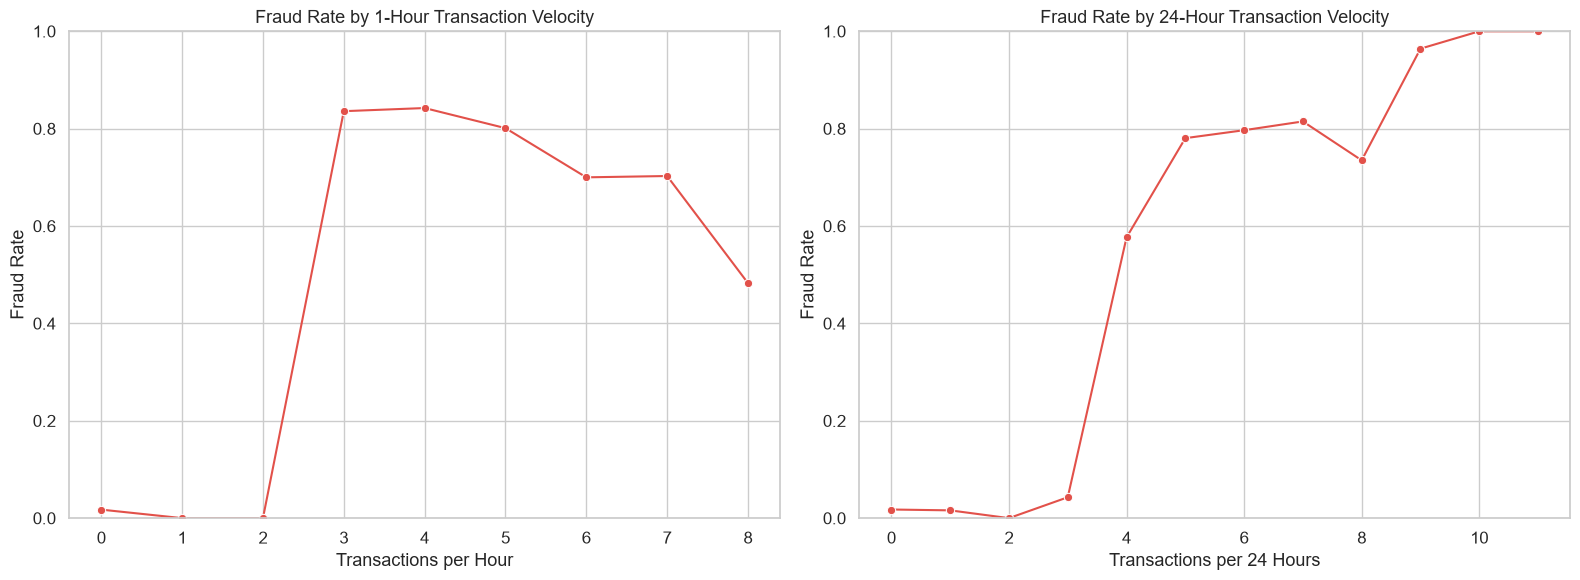

In [19]:
import matplotlib.pyplot as plt  
import seaborn as sns  

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# 1. Fraud Rate by Transaction Velocity (1 Hour)
txn_velocity_1h = (
    cleaned_customer_transaction_data
    .groupby('txn_velocity_1h')['is_fraud']
    .mean()
    .reset_index()
)

sns.lineplot(
    data=txn_velocity_1h,
    x='txn_velocity_1h',
    y='is_fraud',
    marker='o',
    ax=axes[0]
)

axes[0].set_title('Fraud Rate by 1-Hour Transaction Velocity')
axes[0].set_xlabel('Transactions per Hour')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_ylim(0, 1)


# 2. Fraud Rate by Transaction Velocity (24 Hours)
txn_velocity_24h = (
    cleaned_customer_transaction_data
    .groupby('txn_velocity_24h')['is_fraud']
    .mean()
    .reset_index()
)

sns.lineplot(
    data=txn_velocity_24h,
    x='txn_velocity_24h',
    y='is_fraud',
    marker='o',
    ax=axes[1]
)

axes[1].set_title('Fraud Rate by 24-Hour Transaction Velocity')
axes[1].set_xlabel('Transactions per 24 Hours')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_ylim(0, 1)


plt.tight_layout()
plt.show()

In [20]:
txn_velocity_1h 

,txn_velocity_1h,is_fraud
0,0,0.017459
1,1,0.000000
2,2,0.000000
3,3,0.835878
4,4,0.842324
5,5,0.801047
6,6,0.700000
7,7,0.702703
8,8,0.482759


In [21]:
txn_velocity_24h

,txn_velocity_24h,is_fraud
0,0,0.017717
1,1,0.015951
2,2,0.000000
3,3,0.042857
4,4,0.576642
5,5,0.780488
6,6,0.796813
7,7,0.814815
8,8,0.734940
9,9,0.964286


### EDA Summary – 1-Hour Transaction Velocity and Fraud Risk

The analysis shows a strong relationship between **1-hour transaction velocity** and fraud occurrence. Transactions with a velocity of **0–2 transactions per hour** recorded very low fraud rates, ranging from **0% to 1.75%**.

However, the fraud rate increased sharply at **3 transactions per hour**, reaching **83.59%**, and remained high at **4 transactions (84.23%)** and **5 transactions (80.10%)** per hour. Although the fraud rate declined at higher velocity levels, it remained elevated at **70.00% for 6 transactions**, **70.27% for 7 transactions**, and **48.28% for 8 transactions per hour**.

Overall, the results suggest that **rapid transaction activity is strongly associated with fraud in this dataset**, particularly from approximately **3 transactions per hour onwards**. Therefore, `txn_velocity_1h` may be an important behavioural feature for the fraud detection model.



### EDA Summary – 24-Hour Transaction Velocity and Fraud Risk

The analysis shows a strong relationship between **24-hour transaction velocity** and fraud occurrence. Transactions with a velocity of **0–3 transactions within 24 hours** recorded relatively low fraud rates, ranging from **0% to 4.29%**.

A substantial increase was observed from **4 transactions within 24 hours**, where the fraud rate increased to **57.66%**. The fraud rate remained high as transaction velocity increased, reaching **78.05% at 5 transactions**, **79.68% at 6 transactions**, and **81.48% at 7 transactions**.

At very high transaction velocities, the observed fraud rate increased further, reaching **96.43% at 9 transactions** and **100% at 10 and 11 transactions within 24 hours**.

Overall, the findings suggest that **higher 24-hour transaction velocity is strongly associated with fraud in this dataset**. Therefore, `txn_velocity_24h` may be an important behavioural feature for identifying suspicious transaction activity.



#### Fraud Rate by Hour of the Day

In [22]:
import matplotlib.pyplot as plt  # for Data Visualization
import seaborn as sns  # for Data Visualization

In [23]:
cleaned_customer_transaction_data['timestamp'] = pd.to_datetime(cleaned_customer_transaction_data['timestamp']) # Convert the timestamp column to datetime format

# to extract time based features from the timestamp column
cleaned_customer_transaction_data['hour'] = cleaned_customer_transaction_data['timestamp'].dt.hour # to extract the hour from the timestamp column
cleaned_customer_transaction_data['day_of_week'] = cleaned_customer_transaction_data['timestamp'].dt.day_of_week # Monday = 0, Tuesday = 1, ..., Saturday = 5, Sunday = 6
cleaned_customer_transaction_data['month'] = cleaned_customer_transaction_data['timestamp'].dt.month  # Extract the month (1 = January, ..., 12 = December)
cleaned_customer_transaction_data['is_weekend'] = (cleaned_customer_transaction_data['day_of_week'] >= 5).astype(int)  # sees 5 and 6 as weekend days (Saturday and Sunday)

In [24]:
cleaned_customer_transaction_data.head(2)

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,hour,day_of_week,month,is_weekend
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,us,USD,CAD,atm,278.19,278.19,4.25,...,0,0.223,0,0,0.0,0,18,0,10,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,ca,CAD,MXN,web,208.51,154.29,4.24,...,0,0.268,0,1,0.0,0,20,0,10,0


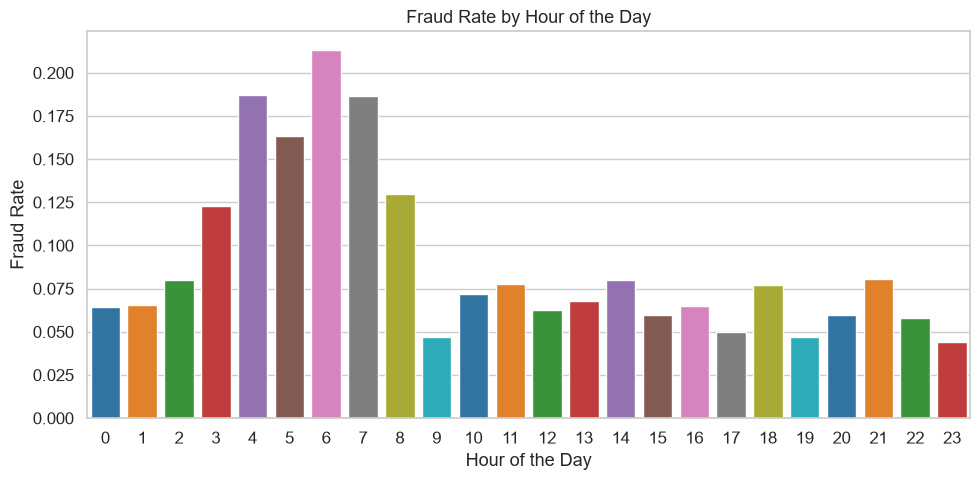

In [25]:
# fraud rate by hour of the day
fraud_rate_by_hour = (
    cleaned_customer_transaction_data
    .groupby('hour')['is_fraud']
    .mean()
    .reset_index()
)

# plot
plt.figure(figsize=(10, 5))

sns.barplot(
    data=fraud_rate_by_hour,
    x='hour',
    y='is_fraud',
    hue='hour',
    palette='tab10',
    legend=False
)

plt.title('Fraud Rate by Hour of the Day')
plt.xlabel('Hour of the Day')   
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

In [26]:
fraud_rate_by_hour

,hour,is_fraud
0,0,0.064159
1,1,0.065327
2,2,0.079903
3,3,0.122917
4,4,0.186879
5,5,0.163482
6,6,0.213362
7,7,0.186788
8,8,0.129512
9,9,0.047059


### EDA Summary – Fraud Rate by Hour of the Day

Fraud occurrence varies across different hours of the day. The highest observed fraud rate occurred at **06:00 (21.34%)**, followed by **04:00 (18.69%)**, **07:00 (18.68%)**, and **05:00 (16.35%)**.

Fraud rates were generally lower during most daytime and evening hours. For example, the fraud rate was **4.71% at 09:00**, **4.98% at 17:00**, **4.68% at 19:00**, and reached its lowest observed level of **4.40% at 23:00**.

Overall, the results suggest that fraud in this dataset is more concentrated during the **early-morning hours, particularly between approximately 04:00 and 07:00**. This indicates that the time at which a transaction occurs may provide useful behavioural information for fraud detection.

Therefore, the engineered `hour` feature may be useful for the fraud detection model. 

In [27]:
import matplotlib.pyplot as plt 
import seaborn as sns 


C:\Users\oyebi\AppData\Local\Temp\ipykernel_6372\3154154805.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fraud_rate_by_account_age, x='account_age_bucket', y='is_fraud', palette = 'tab10')


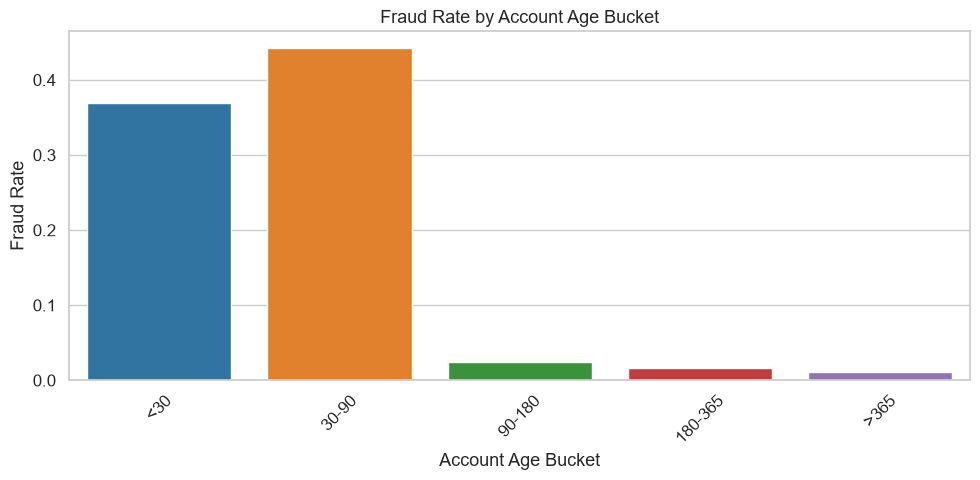

In [28]:
# Create account age buckets
cleaned_customer_transaction_data['account_age_bucket'] = pd.cut(
    cleaned_customer_transaction_data['account_age_days'],
    bins=[0, 30, 90, 180, 365, 2000],
    labels=['<30', '30-90', '90-180', '180-365', '>365']
)

# Calculate fraud rate by account age bucket
fraud_rate_by_account_age = (
    cleaned_customer_transaction_data
    .groupby('account_age_bucket', observed=True)['is_fraud']
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=fraud_rate_by_account_age, x='account_age_bucket', y='is_fraud', palette = 'tab10')

plt.title('Fraud Rate by Account Age Bucket')
plt.xlabel('Account Age Bucket')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
fraud_rate_by_account_age 

,account_age_bucket,is_fraud
0,<30,0.368681
1,30-90,0.442584
2,90-180,0.023736
3,180-365,0.016901
4,>365,0.010534


### EDA Summary – Account Age and Fraud Risk

The analysis revealed a strong relationship between **account age and fraud occurrence**.

The highest fraud rate was observed among accounts aged **30–90 days, at 44.26%**, followed by accounts aged **less than 30 days, at 36.87%**.

In contrast, fraud rates decreased substantially among older accounts. Accounts aged **90–180 days** recorded a fraud rate of only **2.37%**, while accounts aged **180–365 days** and **more than 365 days** recorded fraud rates of **1.69%** and **1.05%**, respectively.

The sharp decline in fraud rates after approximately **90 days** suggests that relatively new accounts are substantially more associated with fraudulent transactions in this dataset than established accounts.

Therefore, `account_age_days` appears to be an **important potential predictive feature** for the fraud detection model. The findings also suggest that the first 90 days of an account's lifecycle may represent a particularly important period for fraud monitoring.


#### Fraud Rate by Device Trust Score

C:\Users\oyebi\AppData\Local\Temp\ipykernel_6372\1840217837.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\oyebi\AppData\Local\Temp\ipykernel_6372\1840217837.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\oyebi\AppData\Local\Temp\ipykernel_6372\1840217837.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


(0.0, 1.0)

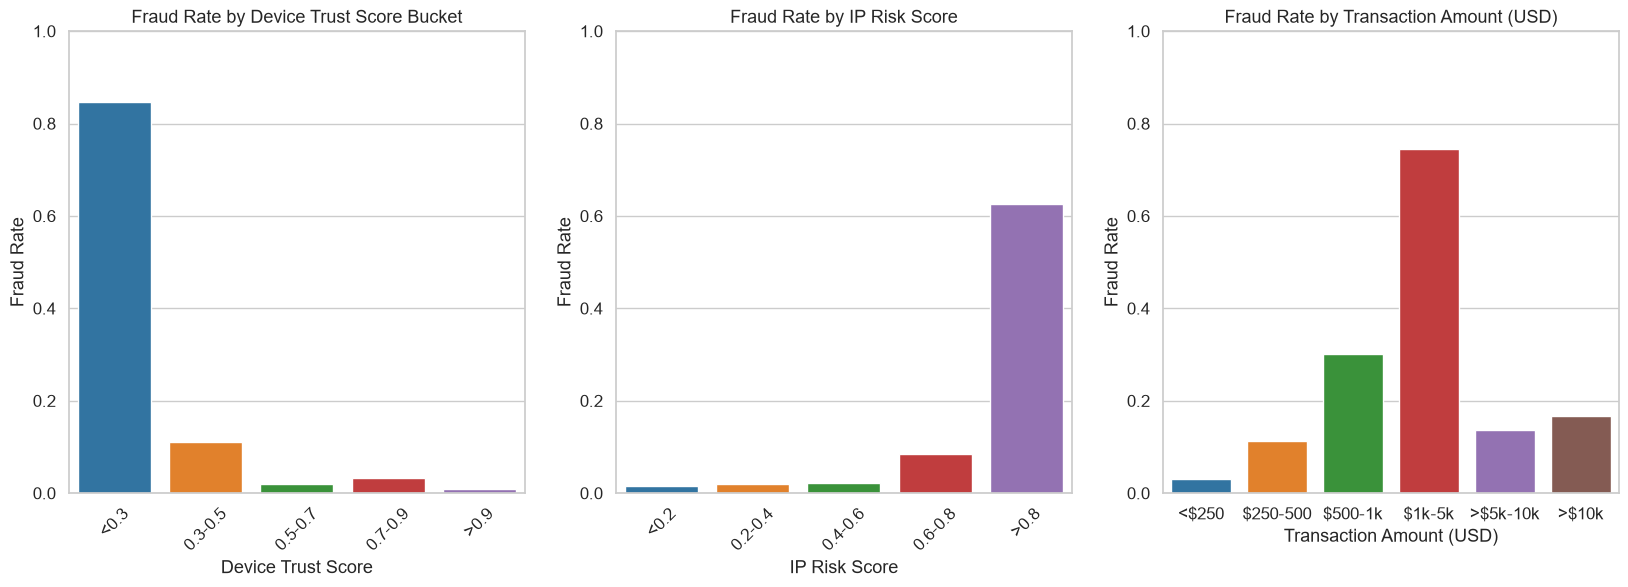

In [30]:
# Create 3 columns
fig, axes = plt.subplots(1, 3, figsize=(20, 6)) 

# 1. Fraud Rate by Device Trust Score

cleaned_customer_transaction_data['device_trust_score_bucket'] = pd.cut(
    cleaned_customer_transaction_data['device_trust_score'],
    bins=[0, 0.3, 0.5, 0.7, 0.9, 1.0],
    labels=['<0.3', '0.3-0.5', '0.5-0.7', '0.7-0.9', '>0.9']
)

fraud_rate_by_device_trust_score = (
    cleaned_customer_transaction_data
    .groupby('device_trust_score_bucket', observed=True)['is_fraud']
    .mean() # This calculates the fraud rate.
    .reset_index()
)

sns.barplot(
    data=fraud_rate_by_device_trust_score,
    x='device_trust_score_bucket',
    y='is_fraud',
    ax=axes[0],
    palette='tab10'
)


axes[0].set_title('Fraud Rate by Device Trust Score Bucket')
axes[0].set_xlabel('Device Trust Score')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better visibility


# 2. Fraud Rate by IP Risk Score

cleaned_customer_transaction_data['ip_risk_score_bucket'] = pd.cut(

    cleaned_customer_transaction_data['ip_risk_score'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.8],
    labels=['<0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '>0.8'],
    include_lowest=True
)


fraud_rate_by_ip_risk_score = (
    cleaned_customer_transaction_data
    .groupby('ip_risk_score_bucket', observed=True)['is_fraud']
    .mean()
    .reset_index()
)

sns.barplot(
    data=fraud_rate_by_ip_risk_score,
    x='ip_risk_score_bucket',
    y='is_fraud',
    ax=axes[1],
    palette='tab10'
)

axes[1].set_title('Fraud Rate by IP Risk Score')
axes[1].set_xlabel('IP Risk Score') 
axes[1].set_ylabel('Fraud Rate')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better visibility



# 3. Fraud Rate by Transaction Amount

cleaned_customer_transaction_data['amount_usd_bucket'] = pd.cut(
    cleaned_customer_transaction_data['amount_usd'],    
    bins=[0, 250, 500, 1000, 5000, 10000,20000], 
    labels=['<$250', '$250-500', '$500-1k', '$1k-5k', '>$5k-10k', '>$10k'],
    include_lowest=True
)   


fraud_rate_by_amount_usd = (
    cleaned_customer_transaction_data
    .groupby('amount_usd_bucket', observed=True)['is_fraud']
    .mean()
    .reset_index()
)

sns.barplot(
    data=fraud_rate_by_amount_usd,
    x='amount_usd_bucket',
    y='is_fraud',
    ax=axes[2],
    palette='tab10'
)

axes[2].set_title('Fraud Rate by Transaction Amount (USD)')
axes[2].set_xlabel('Transaction Amount (USD)')  
axes[2].set_ylabel('Fraud Rate')
axes[2].set_ylim(0, 1)
